In [42]:
import langchain_openai.chat_models
from langgraph.graph import START,END ,StateGraph
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from typing import TypedDict,Literal,Annotated
from pydantic import BaseModel,Field
import os
import operator

In [43]:
load_dotenv()

True

In [44]:
os.environ["CEREBRAS_API_KEY"]

'csk-e586mrjkx4nhfvvxy2w2tk3xdrkkjyevrp46958yrtkfhw6h'

In [55]:
gen_llm=ChatGoogleGenerativeAI(
    model="gemini-3.5-flash"

)
eval_llm=ChatGroq(
      model='llama-3.3-70b-versatile',
    temperature=0.7,
    max_tokens=2000
)
optimize_llm = ChatOpenAI(
    model="gpt-oss-120b",
    base_url="https://api.cerebras.ai/v1",
    api_key=os.environ["CEREBRAS_API_KEY"]
)

In [73]:
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation: Literal["approved", "needs_improvement"]
    feedback:str
    iteration:int
    max_iteration:int

    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]

In [74]:
class struct(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

struc_eval_llm=eval_llm.with_structured_output(struct)

In [75]:

def generate_tweet(state: TweetState):
        messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
        response=gen_llm.invoke(messages).content
        return{
        'tweet': response,
        'tweet_history': [response]
    }

In [76]:
def evaluate_tweet(state: TweetState):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    response=struc_eval_llm.invoke(messages)
    return{
    'evaluation': response.evaluation,
    'feedback': response.feedback,
    'feedback_history': [response.feedback]
}

In [77]:
def optimize_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimize_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [78]:
def check_condition(state: TweetState)->Literal['end','optimize']:
    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return 'end'
    else:
        return 'optimize'

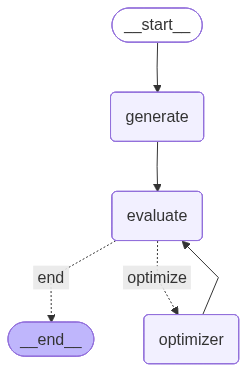

In [79]:
graph=StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimizer',optimize_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')

graph.add_conditional_edges('evaluate',check_condition,{'end':END,'optimize':'optimizer'})
graph.add_edge('optimizer','evaluate')
workflow=graph.compile()
workflow

In [81]:
initial_state={
    'topic':"AI and creativity",
    'iteration':1,
    'max_iteration':4
}
result = workflow.invoke(initial_state)
result

{'topic': 'AI and creativity',
 'tweet': 'AI finally solved my artist’s block: now I spend hours arguing with a bot about how many fingers belong on a hand. 🤖✏️ #AI #Creativity',
 'evaluation': 'approved',
 'feedback': "This tweet excels in originality, humor, and punchiness. The concept of arguing with a bot about the number of fingers on a hand is fresh and amusing, making it likely to genuinely make readers smile. The use of emojis such as 🤖 and ✏️ adds a touch of playfulness, enhancing the tweet's engagement potential. The tweet is well-formed, concise, and under 280 characters, which aligns perfectly with the criteria for a good tweet format. Additionally, the hashtag #AI #Creativity is relevant and could contribute to its virality potential. Overall, the tweet effectively balances creativity and humor, making it scroll-stopping and worthy of retweets or shares.",
 'iteration': 2,
 'max_iteration': 4,
 'tweet_history': [[{'type': 'text',
    'text': 'So glad AI is here to revoluti